# Deep Learning Methods: ResNet50, EfficientNetB0, and Vision Transformer

This notebook implements and trains three deep learning models:
- **ResNet50**: Residual Networks with 50 layers
- **EfficientNetB0**: Mobile-Efficient Networks (Baseline)
- **Vision Transformer (ViT-Base)**: Transformer-based architecture

All use transfer learning with ImageNet pre-trained weights.

In [1]:
# change the default cache directory for PyTorch to a custom location
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TORCH_HOME'] = 'E:/jingxizhang/torch_cache'
os.environ['TORCHINDUCTOR_CACHE_DIR'] = 'E:/jingxizhang/torch_cache/inductor'

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)
import time
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\nLibraries imported successfully!")

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
GPU Memory: 17.09 GB

Libraries imported successfully!


In [3]:
# Load data
print("\nLoading data split...")
data_df = pd.read_csv('e:/jingxizhang/image-classification-project/results/data_split.csv')

train_df = data_df[data_df['split'] == 'train'].reset_index(drop=True)
val_df = data_df[data_df['split'] == 'val'].reset_index(drop=True)
test_df = data_df[data_df['split'] == 'test'].reset_index(drop=True)

num_classes = len(data_df['label'].unique())
print(f"Data loaded: {len(train_df)} train, {len(val_df)} val, {len(test_df)} test")
print(f"Number of classes: {num_classes}")

# Define transform function
def get_transforms(img_size=(224, 224), augmentation=True):
    if augmentation:
        train_transform = transforms.Compose([
            transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    val_test_transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    return train_transform, val_test_transform

print("Transform function defined!")


Loading data split...
Data loaded: 6400 train, 1372 val, 1372 test
Number of classes: 102
Transform function defined!


In [4]:
# Initialize Vision Transformer (ViT-Base)
print("\nInitializing Vision Transformer (ViT-Base)...")
try:
    import timm
    vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
    vit = vit.to(device)
    print("Vision Transformer initialized!")
except Exception as e:
    print(f"Warning: timm not available. Error: {e}")
    vit = None


Initializing Vision Transformer (ViT-Base)...
Vision Transformer initialized!


In [5]:
# Initialize results dictionary
results = {}

print("Results dictionary initialized!")

Results dictionary initialized!


## Section 3: Train Vision Transformer

In [6]:
# Dataset class
class Caltech101Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        try:
            img = Image.open(img_path)
            if img.mode != 'RGB':
                img = img.convert('RGB')
        except Exception as e:
            # Return blank image if loading fails
            print(f"Error loading {img_path}: {e}")
            img = Image.new('RGB', (224, 224))
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

print("Dataset class defined!")

Dataset class defined!


## Section 2: Model Training Functions

In [7]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return total_loss / total, correct / total


def test_model(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_logits = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(inputs)

            preds = outputs.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_logits.append(outputs.cpu())
            all_labels.append(labels.cpu())

    test_labels = torch.cat(all_labels).numpy()
    test_preds = torch.cat(all_preds).numpy()
    test_logits = torch.cat(all_logits).numpy()
    return test_labels, test_preds, test_logits


def train_model(model_name, model, train_loader, val_loader, test_loader, 
                num_epochs=25, learning_rate=0.001, optimizer_type='adam'):
    print(f"\n{'='*70}")
    print(f"Training {model_name} (Optimizer: {optimizer_type.upper()})")
    print(f"{'='*70}")

    device = next(model.parameters()).device
    criterion = nn.CrossEntropyLoss()

    if optimizer_type.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    best_val_acc = 0.0
    patience = 7
    patience_counter = 0

    best_path = f"{model_name}_best.pth"

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step()

        if (epoch + 1) % 1 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, "
                  f"Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    try:
        model.load_state_dict(torch.load(best_path, map_location=device))
    except:
        pass

    training_time = time.time() - start_time

    test_labels, test_preds, test_logits = test_model(model, test_loader, device)

    # Overall metrics (weighted - accounts for class imbalance)
    test_acc = accuracy_score(test_labels, test_preds)
    test_precision = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
    test_recall = recall_score(test_labels, test_preds, average='weighted', zero_division=0)
    test_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
    
    # Macro averages (unweighted - treats all classes equally)
    test_precision_macro = precision_score(test_labels, test_preds, average='macro', zero_division=0)
    test_recall_macro = recall_score(test_labels, test_preds, average='macro', zero_division=0)
    test_f1_macro = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    
    # Per-class accuracy
    per_class_acc = {}
    for class_id in range(num_classes):
        mask = test_labels == class_id
        if mask.sum() > 0:
            per_class_acc[class_id] = accuracy_score(test_labels[mask], test_preds[mask])
        else:
            per_class_acc[class_id] = 0.0
    
    # Top-k accuracy
    top5_preds = np.argsort(test_logits, axis=1)[:, -5:]
    top5_acc = np.mean([test_labels[i] in top5_preds[i] for i in range(len(test_labels))])
    
    top3_preds = np.argsort(test_logits, axis=1)[:, -3:]
    top3_acc = np.mean([test_labels[i] in top3_preds[i] for i in range(len(test_labels))])

    print(f"\n{model_name} Results:")
    print(f"Training time: {training_time:.2f}s ({training_time/60:.1f}m)")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")
    print(f"\n--- Overall Metrics (Weighted) ---")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    print(f"\n--- Macro Averages (Unweighted) ---")
    print(f"Precision (Macro): {test_precision_macro:.4f}")
    print(f"Recall (Macro): {test_recall_macro:.4f}")
    print(f"F1-Score (Macro): {test_f1_macro:.4f}")
    print(f"\n--- Top-k Accuracy ---")
    print(f"Top-3 Accuracy: {top3_acc:.4f}")
    print(f"Top-5 Accuracy: {top5_acc:.4f}")
    print(f"\n--- Per-class Stats ---")
    print(f"Best class accuracy: {max(per_class_acc.values()):.4f}")
    print(f"Worst class accuracy: {min(per_class_acc.values()):.4f}")
    print(f"Average class accuracy: {np.mean(list(per_class_acc.values())):.4f}")

    return {
        'model_name': model_name,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_precision_macro': test_precision_macro,
        'test_recall_macro': test_recall_macro,
        'test_f1_macro': test_f1_macro,
        'per_class_accuracy': per_class_acc,
        'top3_acc': top3_acc,
        'top5_acc': top5_acc,
        'training_time': training_time,
        'test_labels': test_labels,
        'test_preds': test_preds,
        'test_logits': test_logits
    }

## Section 3: Train Main Models

In [8]:
# Create data loaders (224x224 with augmentation)
train_transform, val_test_transform = get_transforms((224, 224), augmentation=True)

train_dataset = Caltech101Dataset(train_df, transform=train_transform)
val_dataset = Caltech101Dataset(val_df, transform=val_test_transform)
test_dataset = Caltech101Dataset(test_df, transform=val_test_transform)

batch_size = 128
num_workers = 0

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)


print(f"Data loaders created (CUDA optimized)!")
print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

# Initialize models
print("\nInitializing models...")

# ResNet50
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

# EfficientNetB0
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, num_classes)
efficientnet = efficientnet.to(device)

print("Models initialized!")

Data loaders created (CUDA optimized)!
Batch size: 128
Train batches: 50, Val batches: 11, Test batches: 11

Initializing models...
Models initialized!


In [9]:
# Train ResNet50
results_main = {}
print("\nTraining ResNet50 with CUDA acceleration...")
results_main['ResNet50'] = train_model('ResNet50', resnet, train_loader, val_loader, 
                                        test_loader, num_epochs=15, learning_rate=0.001)


Training ResNet50 with CUDA acceleration...

Training ResNet50 (Optimizer: ADAM)
Epoch [1/15] - Train Loss: 2.0388, Train Acc: 0.5331, Val Loss: 2.0140, Val Acc: 0.5102
Epoch [2/15] - Train Loss: 0.9584, Train Acc: 0.7300, Val Loss: 1.5729, Val Acc: 0.6290
Epoch [3/15] - Train Loss: 0.6549, Train Acc: 0.8133, Val Loss: 1.1254, Val Acc: 0.6990
Epoch [4/15] - Train Loss: 0.4718, Train Acc: 0.8605, Val Loss: 1.5105, Val Acc: 0.6516
Epoch [5/15] - Train Loss: 0.3988, Train Acc: 0.8798, Val Loss: 1.0090, Val Acc: 0.7340
Epoch [6/15] - Train Loss: 0.3103, Train Acc: 0.9031, Val Loss: 0.9761, Val Acc: 0.7507
Epoch [7/15] - Train Loss: 0.2527, Train Acc: 0.9242, Val Loss: 1.1626, Val Acc: 0.7245
Epoch [8/15] - Train Loss: 0.1180, Train Acc: 0.9663, Val Loss: 0.4786, Val Acc: 0.8666
Epoch [9/15] - Train Loss: 0.0452, Train Acc: 0.9891, Val Loss: 0.4264, Val Acc: 0.8834
Epoch [10/15] - Train Loss: 0.0258, Train Acc: 0.9934, Val Loss: 0.4258, Val Acc: 0.8921
Epoch [11/15] - Train Loss: 0.0194, T

In [10]:
# Train Vision Transformer
print("\nTraining Vision Transformer with CUDA acceleration...")
if vit is not None:
    results_main['ViT-Base'] = train_model('ViT-Base', vit, train_loader, val_loader, 
                                      test_loader, num_epochs=15, learning_rate=0.001)
else:
    print("Vision Transformer not available (timm not installed)")


Training Vision Transformer with CUDA acceleration...

Training ViT-Base (Optimizer: ADAM)
Epoch [1/15] - Train Loss: 4.4739, Train Acc: 0.1225, Val Loss: 3.9914, Val Acc: 0.1749
Epoch [2/15] - Train Loss: 3.8639, Train Acc: 0.1895, Val Loss: 3.8224, Val Acc: 0.1793
Epoch [3/15] - Train Loss: 3.5008, Train Acc: 0.2452, Val Loss: 3.3233, Val Acc: 0.2923
Epoch [4/15] - Train Loss: 3.1252, Train Acc: 0.2998, Val Loss: 3.3278, Val Acc: 0.2573
Epoch [5/15] - Train Loss: 2.8752, Train Acc: 0.3409, Val Loss: 3.0972, Val Acc: 0.2959
Epoch [6/15] - Train Loss: 2.7223, Train Acc: 0.3627, Val Loss: 2.8828, Val Acc: 0.3520
Epoch [7/15] - Train Loss: 2.5401, Train Acc: 0.3916, Val Loss: 2.7426, Val Acc: 0.3724
Epoch [8/15] - Train Loss: 2.1980, Train Acc: 0.4559, Val Loss: 2.6320, Val Acc: 0.3812
Epoch [9/15] - Train Loss: 1.9144, Train Acc: 0.5073, Val Loss: 2.5988, Val Acc: 0.4125
Epoch [10/15] - Train Loss: 1.7951, Train Acc: 0.5380, Val Loss: 2.7137, Val Acc: 0.4001
Epoch [11/15] - Train Loss:

In [11]:
# Train EfficientNetB0
print("\nTraining EfficientNetB0 with CUDA acceleration...")
results_main['EfficientNetB0'] = train_model('EfficientNetB0', efficientnet, train_loader, val_loader, 
                                              test_loader, num_epochs=15, learning_rate=0.001)


Training EfficientNetB0 with CUDA acceleration...

Training EfficientNetB0 (Optimizer: ADAM)
Epoch [1/15] - Train Loss: 1.3665, Train Acc: 0.7405, Val Loss: 0.3354, Val Acc: 0.9023
Epoch [2/15] - Train Loss: 0.2164, Train Acc: 0.9414, Val Loss: 0.3381, Val Acc: 0.9001
Epoch [3/15] - Train Loss: 0.1160, Train Acc: 0.9650, Val Loss: 0.2923, Val Acc: 0.9140
Epoch [4/15] - Train Loss: 0.0870, Train Acc: 0.9752, Val Loss: 0.2799, Val Acc: 0.9191
Epoch [5/15] - Train Loss: 0.0852, Train Acc: 0.9755, Val Loss: 0.3200, Val Acc: 0.9060
Epoch [6/15] - Train Loss: 0.0576, Train Acc: 0.9838, Val Loss: 0.3044, Val Acc: 0.9184
Epoch [7/15] - Train Loss: 0.0508, Train Acc: 0.9852, Val Loss: 0.2864, Val Acc: 0.9286
Epoch [8/15] - Train Loss: 0.0243, Train Acc: 0.9941, Val Loss: 0.2242, Val Acc: 0.9402
Epoch [9/15] - Train Loss: 0.0119, Train Acc: 0.9969, Val Loss: 0.2209, Val Acc: 0.9475
Epoch [10/15] - Train Loss: 0.0104, Train Acc: 0.9966, Val Loss: 0.2444, Val Acc: 0.9395
Epoch [11/15] - Train Los

## Section 4: Ablation Study 1 - Optimizer Comparison (SGD vs Adam)

In [16]:
# Create comprehensive comparison table for all models
models_to_compare = list(results_main.keys())
comparison_data = {
    'Model': models_to_compare,
    'Test Accuracy': [results_main[m]['test_acc'] for m in models_to_compare],
    'Precision (Weighted)': [results_main[m]['test_precision'] for m in models_to_compare],
    'Recall (Weighted)': [results_main[m]['test_recall'] for m in models_to_compare],
    'F1-Score (Weighted)': [results_main[m]['test_f1'] for m in models_to_compare],
    'Precision (Macro)': [results_main[m]['test_precision_macro'] for m in models_to_compare],
    'Recall (Macro)': [results_main[m]['test_recall_macro'] for m in models_to_compare],
    'F1-Score (Macro)': [results_main[m]['test_f1_macro'] for m in models_to_compare],
    'Top-3 Accuracy': [results_main[m]['top3_acc'] for m in models_to_compare],
    'Top-5 Accuracy': [results_main[m]['top5_acc'] for m in models_to_compare],
    'Training Time (m)': [results_main[m]['training_time']/60 for m in models_to_compare]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*150)
print("DEEP LEARNING MODELS COMPREHENSIVE COMPARISON")
print("="*150)
print(comparison_df.to_string(index=False))
print("="*150)


DEEP LEARNING MODELS COMPREHENSIVE COMPARISON
         Model  Test Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  Top-3 Accuracy  Top-5 Accuracy  Training Time (m)
      ResNet50       0.899417              0.908434           0.899417             0.897894           0.885119        0.861440          0.864410        0.958455        0.975219           4.542280
      ViT-Base       0.456997              0.485829           0.456997             0.449652           0.358261        0.331714          0.325794        0.596210        0.670554           7.778347
EfficientNetB0       0.941691              0.947627           0.941691             0.941770           0.930657        0.922763          0.922304        0.991254        0.995627           4.303414


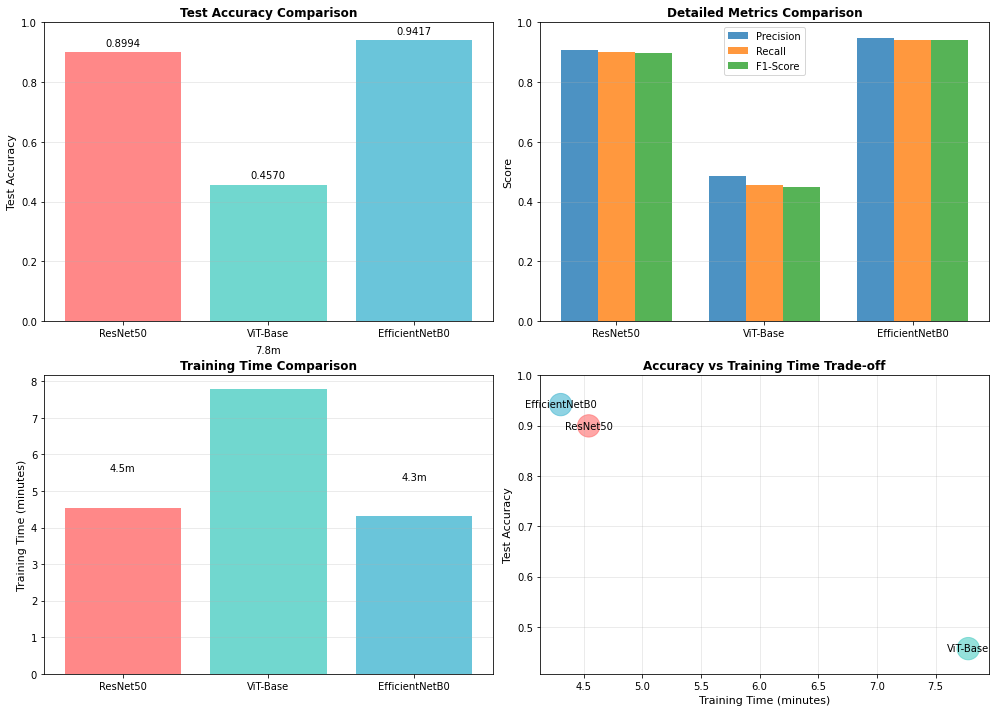


Comparison visualization saved!


In [17]:
# Visualize comparison for all 3 DL models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_to_compare = list(results_main.keys())
accuracies = [results_main[m]['test_acc'] for m in models_to_compare]
precisions = [results_main[m]['test_precision'] for m in models_to_compare]
recalls = [results_main[m]['test_recall'] for m in models_to_compare]
f1s = [results_main[m]['test_f1'] for m in models_to_compare]
times = [results_main[m]['training_time']/60 for m in models_to_compare]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Accuracy
axes[0, 0].bar(models_to_compare, accuracies, color=colors[:len(models_to_compare)], alpha=0.8)
axes[0, 0].set_ylabel('Test Accuracy', fontsize=11)
axes[0, 0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3)

# Metrics
x_pos = np.arange(len(models_to_compare))
width = 0.25
axes[0, 1].bar(x_pos - width, precisions, width, label='Precision', alpha=0.8)
axes[0, 1].bar(x_pos, recalls, width, label='Recall', alpha=0.8)
axes[0, 1].bar(x_pos + width, f1s, width, label='F1-Score', alpha=0.8)
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_title('Detailed Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models_to_compare)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Training time
axes[1, 0].bar(models_to_compare, times, color=colors[:len(models_to_compare)], alpha=0.8)
axes[1, 0].set_ylabel('Training Time (minutes)', fontsize=11)
axes[1, 0].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
for i, v in enumerate(times):
    axes[1, 0].text(i, v + 1, f'{v:.1f}m', ha='center', fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3)

# Accuracy vs Time scatter
axes[1, 1].scatter(times, accuracies, s=500, alpha=0.6, c=colors[:len(models_to_compare)])
for i, txt in enumerate(models_to_compare):
    axes[1, 1].annotate(txt, (times[i], accuracies[i]), fontsize=10, ha='center', va='center')
axes[1, 1].set_xlabel('Training Time (minutes)', fontsize=11)
axes[1, 1].set_ylabel('Test Accuracy', fontsize=11)
axes[1, 1].set_title('Accuracy vs Training Time Trade-off', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([min(accuracies)-0.05, 1])
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('e:/jingxizhang/image-classification-project/figures/03_deep_learning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComparison visualization saved!")

## Section 5: Ablation Study 2 - Image Size Comparison

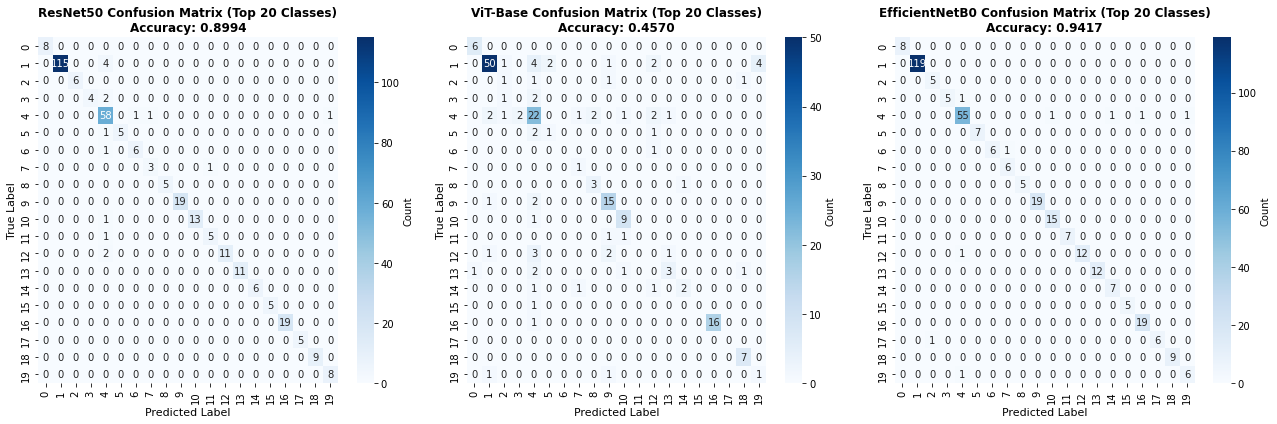

Confusion matrices saved!


In [18]:
# Confusion matrices for all 3 models
num_models = len(results_main)
fig, axes = plt.subplots(1, num_models, figsize=(6*num_models, 6))

if num_models == 1:
    axes = [axes]

for idx, (model_name, ax) in enumerate(zip(results_main.keys(), axes)):
    cm = confusion_matrix(results_main[model_name]['test_labels'], results_main[model_name]['test_preds'])
    
    # Show only top-left 20x20 for visibility
    sns.heatmap(cm[:20, :20], annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax, cbar_kws={'label': 'Count'})
    ax.set_title(f'{model_name} Confusion Matrix (Top 20 Classes)\nAccuracy: {results_main[model_name]["test_acc"]:.4f}', 
                fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('e:/jingxizhang/image-classification-project/figures/03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrices saved!")

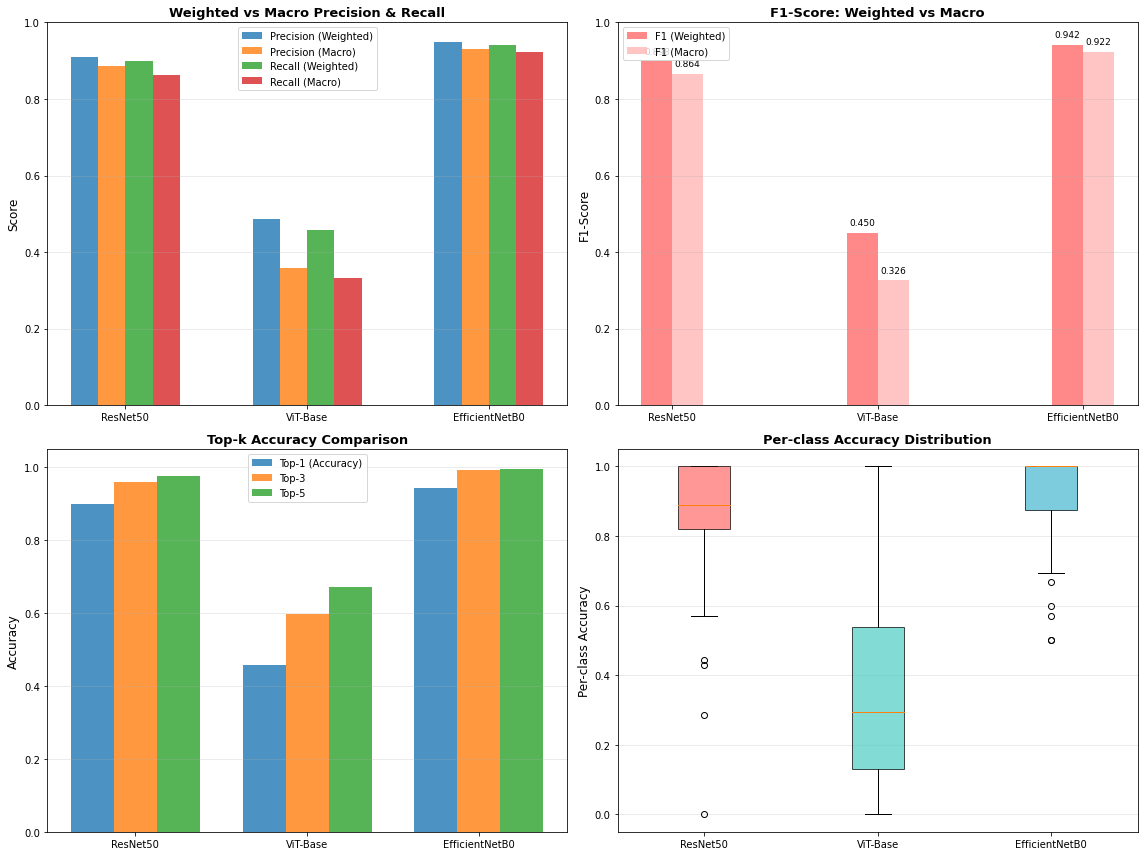


Enhanced metrics visualization saved!


In [15]:

# Visualize enhanced metrics comparing all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_to_compare = list(results_main.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(models_to_compare)]

# 1. Weighted vs Macro Metrics Comparison
x_pos = np.arange(len(models_to_compare))
width = 0.15

axes[0, 0].bar(x_pos - width*1.5, [results_main[m]['test_precision'] for m in models_to_compare], width, label='Precision (Weighted)', alpha=0.8)
axes[0, 0].bar(x_pos - width*0.5, [results_main[m]['test_precision_macro'] for m in models_to_compare], width, label='Precision (Macro)', alpha=0.8)
axes[0, 0].bar(x_pos + width*0.5, [results_main[m]['test_recall'] for m in models_to_compare], width, label='Recall (Weighted)', alpha=0.8)
axes[0, 0].bar(x_pos + width*1.5, [results_main[m]['test_recall_macro'] for m in models_to_compare], width, label='Recall (Macro)', alpha=0.8)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Weighted vs Macro Precision & Recall', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models_to_compare)
axes[0, 0].legend(fontsize=10)
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. F1-Score Comparison (Weighted vs Macro)
axes[0, 1].bar(x_pos - width/2, [results_main[m]['test_f1'] for m in models_to_compare], width, label='F1 (Weighted)', alpha=0.8, color='#FF6B6B')
axes[0, 1].bar(x_pos + width/2, [results_main[m]['test_f1_macro'] for m in models_to_compare], width, label='F1 (Macro)', alpha=0.8, color='#FFB6B6')
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score: Weighted vs Macro', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models_to_compare)
axes[0, 1].legend(fontsize=10)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, m in enumerate(models_to_compare):
    axes[0, 1].text(i - width/2, results_main[m]['test_f1'] + 0.02, f"{results_main[m]['test_f1']:.3f}", ha='center', fontsize=9)
    axes[0, 1].text(i + width/2, results_main[m]['test_f1_macro'] + 0.02, f"{results_main[m]['test_f1_macro']:.3f}", ha='center', fontsize=9)

# 3. Top-k Accuracy Comparison
x_pos = np.arange(len(models_to_compare))
width = 0.25
axes[1, 0].bar(x_pos - width, [results_main[m]['test_acc'] for m in models_to_compare], width, label='Top-1 (Accuracy)', alpha=0.8)
axes[1, 0].bar(x_pos, [results_main[m]['top3_acc'] for m in models_to_compare], width, label='Top-3', alpha=0.8)
axes[1, 0].bar(x_pos + width, [results_main[m]['top5_acc'] for m in models_to_compare], width, label='Top-5', alpha=0.8)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('Top-k Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models_to_compare)
axes[1, 0].legend(fontsize=10)
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Per-class accuracy distribution (box plot)
per_class_accs_by_model = []
labels_per_model = []
for model_name in models_to_compare:
    per_class_vals = list(results_main[model_name]['per_class_accuracy'].values())
    per_class_accs_by_model.append(per_class_vals)
    labels_per_model.append(model_name)

bp = axes[1, 1].boxplot(per_class_accs_by_model, labels=labels_per_model, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_ylabel('Per-class Accuracy', fontsize=12)
axes[1, 1].set_title('Per-class Accuracy Distribution', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig('e:/jingxizhang/image-classification-project/figures/03_enhanced_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEnhanced metrics visualization saved!")


In [19]:
# Save comprehensive evaluation metrics to CSV for report
metrics_report = []

for model_name in results_main.keys():
    metrics_report.append({
        'Model': model_name,
        'Test Accuracy': f"{results_main[model_name]['test_acc']:.4f}",
        'Precision (Weighted)': f"{results_main[model_name]['test_precision']:.4f}",
        'Recall (Weighted)': f"{results_main[model_name]['test_recall']:.4f}",
        'F1-Score (Weighted)': f"{results_main[model_name]['test_f1']:.4f}",
        'Precision (Macro)': f"{results_main[model_name]['test_precision_macro']:.4f}",
        'Recall (Macro)': f"{results_main[model_name]['test_recall_macro']:.4f}",
        'F1-Score (Macro)': f"{results_main[model_name]['test_f1_macro']:.4f}",
        'Top-3 Accuracy': f"{results_main[model_name]['top3_acc']:.4f}",
        'Top-5 Accuracy': f"{results_main[model_name]['top5_acc']:.4f}",
        'Per-Class Mean Accuracy': f"{np.mean(list(results_main[model_name]['per_class_accuracy'].values())):.4f}",
        'Per-Class Std Dev': f"{np.std(list(results_main[model_name]['per_class_accuracy'].values())):.4f}",
        'Best Class Accuracy': f"{max(results_main[model_name]['per_class_accuracy'].values()):.4f}",
        'Worst Class Accuracy': f"{min(results_main[model_name]['per_class_accuracy'].values()):.4f}",
        'Training Time (seconds)': f"{results_main[model_name]['training_time']:.2f}",
        'Training Time (minutes)': f"{results_main[model_name]['training_time']/60:.2f}"
    })

report_df = pd.DataFrame(metrics_report)

# Save to CSV
report_path = 'e:/jingxizhang/image-classification-project/results/model_evaluation_metrics.csv'
report_df.to_csv(report_path, index=False)

print("\n" + "="*100)
print("EVALUATION METRICS SAVED TO CSV")
print("="*100)
print(report_df.to_string(index=False))
print("="*100)
print(f"\nMetrics saved to: {report_path}")



EVALUATION METRICS SAVED TO CSV
         Model Test Accuracy Precision (Weighted) Recall (Weighted) F1-Score (Weighted) Precision (Macro) Recall (Macro) F1-Score (Macro) Top-3 Accuracy Top-5 Accuracy Per-Class Mean Accuracy Per-Class Std Dev Best Class Accuracy Worst Class Accuracy Training Time (seconds) Training Time (minutes)
      ResNet50        0.8994               0.9084            0.8994              0.8979            0.8851         0.8614           0.8644         0.9585         0.9752                  0.8614            0.1693              1.0000               0.0000                  272.54                    4.54
      ViT-Base        0.4570               0.4858            0.4570              0.4497            0.3583         0.3317           0.3258         0.5962         0.6706                  0.3317            0.2682              1.0000               0.0000                  466.70                    7.78
EfficientNetB0        0.9417               0.9476            0.9417   